# Representations: choosing the chart you optimise in

Every method in hypeGRL minimises a loss built from the **pairwise hyperbolic
distances** between embedded points. That loss never sees coordinates:
re-express a configuration in another chart and its value does not change.

Yet the `Representation` you hold that configuration in — the coordinates the
embedding is stored in, together with the metric the optimiser is told those
coordinates carry — changes where the optimiser ends up, sometimes decisively.
Two of the three charts below store the *same* numbers and differ only in that
second half.

This tutorial explains why, and what the settings of `representation=` actually
buy you. Two of the five — `"ball"` and `"hyperboloid"`, the charts most of the
hyperbolic-embedding literature is written in — are ruled out in §1 on grounds
that have nothing to do with the optimiser: they cannot represent the radii real
graphs need. The rest is about choosing among the three that survive:
`"polar"`, `"tangent"` and `"exact_polar"`.

## 1. What is already decided, and what is not

Two questions are settled before this tutorial starts.

**The geometry.** We are embedding in hyperbolic space $\mathbb{H}^{D+1}$. That is
the modelling assumption behind every method here, and it is not what a chart
changes: ball, hyperboloid, polar and tangent are all *exact* coordinate systems
for the same space, and each one's `dist()` returns the same hyperbolic distance.

**Which coordinates can represent the radii we need.** Real graphs put low-degree
nodes at large radius, and two of the charts break there — the Poincaré ball
saturates (every point past $r \approx 8.4$ collapses onto a distance ceiling of
$16.811243$) and the hyperboloid's $\cosh r$ overflows and cancels. That is the
subject of [Poincaré vs Lorentz](poincare_vs_lorentz.ipynb), and it is a question
about *representable range*.

Three charts survive that test — **polar**, **tangent** and **exact polar**, all
exact past $r \approx 350$. Choosing among *those* is a different question, and
it is the subject of this tutorial: not what the numbers can represent, but
**how the optimiser moves them**.

In [1]:
import geoopt
import matplotlib.pyplot as plt
import numpy as np
import torch

from hypegrl.inference.riemannian_optimizer import riemannian_optimize
from hypegrl.manifolds.polar import polar_distances_torch
from hypegrl.representations import (
    ExactPolarRepresentation,
    PolarRepresentation,
    TangentRepresentation,
)

torch.set_default_dtype(torch.float64)

CHARTS = {
    "polar  (w = 1)":        PolarRepresentation,
    "tangent  (w = r)":      TangentRepresentation,
    "exact  (w = sinh r)":   ExactPolarRepresentation,
}

## 2. "The gradient" is not a property of the loss alone

Every gradient-based method in hypeGRL has the same two-stage shape. First an
**initialisation** — a constructed one for some methods (HyperMap's greedy insertion,
D-Mercator's likelihood-refined angles, Hydra+'s spectral solve), a small random draw
near the origin for others — and then a **refinement**, which is gradient descent on
that method's loss. The chart plays no part in the first stage and decides the second,
so it is worth being precise about what a gradient step actually is.

Where does the gradient step $x \leftarrow x - \lambda\nabla f$ come from? The usual
derivation: among all steps $\delta x$ of a **fixed size**, take the one that decreases
$f$ the most. To first order $\delta f = \nabla f^\top \delta x$, and Cauchy–Schwarz
bounds that by $\lVert\nabla f\rVert\,\lVert\delta x\rVert$, with equality exactly when
the two are parallel — so the extreme steps lie along $\nabla f$, and the descending one
is $\delta x \propto -\nabla f$.

The hidden ingredient is **"of a fixed size"**. The constraint was written with the
Euclidean norm $\lVert\delta x\rVert^2 = \sum_i \delta x_i^2$, which says every
coordinate is equally expensive to change. That is an assumption about the parameters,
not a fact about $f$ — and it stops being defensible as soon as the coordinates mean
different things.

Ordinary polar coordinates in the plane are enough to see that. A point is
$(r, \theta)$, and the two partial derivatives are not the same kind of quantity:
$\partial f/\partial r$ carries units of *inverse length*, while
$\partial f/\partial\theta$ is *dimensionless*. Summing $\delta r^2 + \delta\theta^2$
adds a length to an angle, and no learning rate repairs that. **Steepest descent is not
defined until you say what a step costs.**

Write that cost as a quadratic form,

$$\lVert \delta x \rVert_G^2 \;=\; \delta x^\top G\, \delta x ,$$

and here one $G$ is singled out — not by modelling taste, but by the geometry: the one
that measures the *distance the point actually moves*. In the plane, that is arc length,

$$\lVert \delta x \rVert^2 \;=\; \delta r^2 + r^2\,\delta\theta^2 ,
\qquad G = \operatorname{diag}(1,\; r^2).$$

Running the same Cauchy–Schwarz argument in the inner product $G$ defines gives the
step. Writing the change as $\delta f = \langle G^{-1}\nabla f,\; \delta x\rangle_G$
bounds its magnitude by $\lVert\nabla f\rVert_{G^{-1}}\,\lVert\delta x\rVert_G$, with
equality exactly when the two arguments are parallel — so the extreme steps are the ones
along $G^{-1}\nabla f$, and the descending one is

$$\boxed{\;\delta x \;\propto\; -\,G^{-1}\nabla f\;}$$

so the angular component gets divided by $r^2$. Plain gradient descent is the special
case $G = I$ — **a choice, not a neutral default**, and a different one from the arc
length just written down: nothing forces an optimiser to measure steps the way the space
does. (The same structure appears under other names: the *natural gradient* takes $G$ to
be the Fisher information, so that steps are measured in distance between distributions
rather than between parameters. We will come back to it, because using the true metric of
the space is exactly what one of our three charts does.)

### The same question in hyperbolic space

One formula is imported from hyperbolic trigonometry, the law of cosines: for two
points $(r_1,\theta_1)$ and $(r_2,\theta_2)$,

$$\cosh d_H \;=\; \cosh r_1 \cosh r_2 \;-\; \sinh r_1 \sinh r_2 \cos\Delta\theta .$$

Put both points at the same radius $r$. Using $\cosh^2 r - \sinh^2 r = 1$ and
$1 - \cos\Delta\theta = 2\sin^2(\Delta\theta/2)$ this collapses to
$\cosh d_H = 1 + 2\sinh^2(r)\,\sin^2(\Delta\theta/2)$, and expanding for small
$\Delta\theta$ (with $\cosh d_H \approx 1 + d_H^2/2$ and $\sin x \approx x$) leaves
$d_H \approx \sinh(r)\,\Delta\theta$. The radial part needs no derivation — $r$ *is*
distance from the origin along a fixed direction — and the two displacements are
perpendicular, so they add in quadrature:

$$\lVert \delta x \rVert^2 \;=\; \delta r^2 \;+\; \sinh^2(r)\,\delta\theta^2 .$$

That is the same cost we just wrote down for the plane, with one substitution.
**Hyperbolic space differs in exactly one respect**: a radian at radius $r$ spans an
arc of $\sinh r$ instead of $r$, so a circle of radius $r$ has circumference
$2\pi\sinh r$ rather than $2\pi r$. That exponential is the entire reason one embeds
trees hyperbolically, and the entire reason the optimisation is awkward. It is one
fact wearing two hats.

The practical reading: angular coordinates get exponentially more expensive as you
move outward.

In [2]:
# How far does a point actually move when we change its angle by 0.001 rad?
delta_theta = 1e-3
for r in (1.0, 5.0, 20.0):
    euclid = r * delta_theta                      # flat plane:  arc = r * dtheta
    hyper = np.sinh(r) * delta_theta              # hyperbolic:  arc = sinh(r) * dtheta
    print(f"r = {r:5.1f} | flat arc {euclid:12.3f} | hyperbolic arc {hyper:15.3f}")

r =   1.0 | flat arc        0.001 | hyperbolic arc           0.001
r =   5.0 | flat arc        0.005 | hyperbolic arc           0.074
r =  20.0 | flat arc        0.020 | hyperbolic arc      242582.598


The coordinate change is identical in all three rows. The distance actually
travelled differs by eight orders of magnitude. Any optimiser that treats
$\delta\theta$ as "just another parameter" is implicitly claiming these are
equally expensive moves.

## 3. Three charts, three choices of $w$

Section 2 made two points. Hyperbolic space charges $\sinh(r)\,\delta\theta$ for an
angular step — and the optimiser is free to *disagree*, because $G$ is a choice, and
plain gradient descent quietly chooses $G = I$.

In this library that choice is bundled into one object. A `Representation` fixes the
coordinates an embedding is stored in **and** the metric the optimiser is told those
coordinates carry, and it is the pair that decides what a turn costs. Sometimes the
coordinates do the work and sometimes they do not, which is why the three charts left
standing after §1 are not distinguished on the same grounds.

One notational shift first: §2 used a single angle $\theta$, which is all the plane
needs. A direction in $\mathbb{H}^{D+1}$ takes $D$ angles, so we carry it as a **unit
vector** $v \in \mathbb{S}^D$ instead — for $D = 1$ that is exactly
$v = (\cos\theta, \sin\theta)$. Read $(r, v)$ below wherever §2 wrote $(r, \theta)$.

- `polar` — the radius $r$ and the unit direction $v$ as two *independent*
  parameters, a plain radius and a direction on a sphere;
- `exact_polar` — the same $(r, v)$, but coupled by the warped metric §2 derived, so
  that a turn is charged its true arc length;
- `tangent` — a single Cartesian vector $z = r\,v$, stepped as an ordinary Euclidean
  parameter, with $r = \lVert z \rVert$ and the direction $z/\lVert z \rVert$.

The first two store *identical* numbers and differ only in the declared metric; the
third differs in the coordinates themselves. All three describe the same space and
compute the same distances. What differs is the price each one puts on turning.
Writing $g_{\mathbb{S}^D}$ for the ordinary metric on the unit sphere — the
$\delta\theta^2$ of §2, now on $\mathbb{S}^D$ — all three take the form

$$g_w \;=\; dr^2 \;+\; w(r)^2\, g_{\mathbb{S}^D},$$

and differ *only* in the scalar function $w$:

| chart | $w(r)$ | what it says an angle costs |
|---|---|---|
| `polar` | $1$ | the same as a radius, at every radius |
| `tangent` | $r$ | what it costs in **flat** space — the polar metric of §2 |
| `exact_polar` | $\sinh r$ | the truth in $\mathbb{H}^{D+1}$ |

The middle row is worth pausing on: the Euclidean polar metric we derived above,
$G = \operatorname{diag}(1, r^2)$, is not merely an analogy for the tangent chart —
it *is* the tangent chart, applied to a hyperbolic space.

Under the step rule this gives $\delta\theta \propto -(\partial f/\partial\theta)/w^2$,
while the radial component carries no $w$ at all. So the charts differ **only in
the angular direction**, and the difference grows without bound with radius.

Below: one step on the same loss $f = d_H(p, q)$ from the same starting point,
under each chart. Same loss, same minimum — three different paths.

In [3]:
def one_step(cls, r_p, theta_p, r_q, theta_q, lr):
    '''One RiemannianSGD step on f = d_H(p, q).

    Returns p's coordinate changes and, as `moved`, the hyperbolic distance it
    actually travelled.
    '''
    r = np.array([r_p, r_q])
    v = np.array([[np.cos(theta_p), np.sin(theta_p)],
                  [np.cos(theta_q), np.sin(theta_q)]])
    rep = cls.from_polar(r, v)
    opt = geoopt.optim.RiemannianSGD(rep.parameters(), lr=lr, stabilize=None)

    # The loss is the single distance d_H(p, q) -- entry (0, 1) of the pairwise
    # matrix. backward() fills in df/d(this chart's own parameters); the step
    # that follows is where the chart's metric enters.
    opt.zero_grad()
    rep.dist()[0, 1].backward()
    opt.step()

    # How far p actually moved: the distance between p-before and p-after, fed
    # to the same polar distance function as a pair of (radius, direction) rows.
    r1, v1 = rep.to_polar()
    moved = polar_distances_torch(
        torch.tensor([r_p, r1[0].item()]),
        torch.stack([torch.tensor(v[0]), v1[0].detach()]),
    )[0, 1].item()

    theta1 = np.arctan2(v1[0, 1].item(), v1[0, 0].item())   # signed turn, for reporting
    return r1[0].item() - r_p, theta1 - theta_p, moved


THETA_Q, R_Q, LR = np.radians(70.0), 2.5, 0.5
print(f"One step of size {LR} on f = d_H(p, q), with q at (r=2.5, 70 deg)\n")
for r_p in (4.0, 20.0):
    print(f"  p starts at r = {r_p}")
    for name, cls in CHARTS.items():
        dr, dth, moved = one_step(cls, r_p, 0.0, R_Q, THETA_Q, LR)
        print(f"    {name:22s} dr = {dr:+8.5f}   dtheta = {np.degrees(dth):+9.4f} deg"
              f"   moved = {moved:9.6f}")
    print()

One step of size 0.5 on f = d_H(p, q), with q at (r=2.5, 70 deg)

  p starts at r = 4.0


    polar  (w = 1)         dr = -0.47868   dtheta =  +34.9523 deg   moved =  5.127526
    tangent  (w = r)       dr = -0.49498   dtheta =   +2.8577 deg   moved =  1.115366
    exact  (w = sinh r)    dr = -0.49887   dtheta =   +0.0923 deg   moved =  0.500000

  p starts at r = 20.0
    polar  (w = 1)         dr = -0.50000   dtheta =  +34.9785 deg   moved = 37.095562
    tangent  (w = r)       dr = -0.49997   dtheta =   +0.1028 deg   moved = 25.467084
    exact  (w = sinh r)    dr = -0.50000   dtheta =   +0.0000 deg   moved =  0.500000



Three things to read off.

**The charts disagree at every radius shown, and the gap grows without bound.** The
three values of $w$ separate them: at $r = 1$ they are $1$, $1$ and $1.18$ — nearly
the same chart — but by $r = 4$ they are $1$, $4$ and $27.3$, and by $r = 20$, $1$,
$20$ and $2.4\times10^{8}$. The table shows the consequence. Already at $r = 4$ the
angular steps span a factor of 380; by $r = 20$ the exact chart has stopped turning
entirely while polar still turns the same 35°. Polar's angular step is nearly
radius-independent, tangent's falls off roughly like $1/r^2$, and the exact chart's
like $1/\sinh^2 r$. Chart choice is therefore a non-issue for an embedding that
stays near the origin, and the dominant effect for one that does not.

**Only the exact chart takes the step it was asked for.** Its `moved` column reads
$0.500000$ at both radii — exactly the requested $\lambda$. That is not luck:
$f = d_H(p,q)$ is a distance function, so $\lVert\nabla_{\!H} f\rVert = 1$
everywhere, and a step under the true metric therefore covers a distance of exactly
$\lambda$ whatever the radius. This is what makes `exact_polar`'s learning rate
interpretable as a length. Under the other two, $\lambda$ is a step in
*coordinates*, and how far that carries the point depends on where it sits — at
$r = 20$, polar travels 74 times further than asked, tangent 51 times.

**The exact chart has almost stopped turning.** Its angular step is divided by
$\sinh^2 r$, which at $r = 20$ is $\sim 10^{17}$. It is not malfunctioning — it is
correctly reporting that rotating a point at that radius is enormously expensive.
Whether that is the *useful* thing to report is what the rest of this tutorial is
about.

## 4. A toy where the difference decides the answer

Put $K$ points on $\mathbb{H}^2$, all at the same large radius $r_0 = 20$. The
**target** is the regular $K$-gon — same radius, angles equally spaced. The
**start** keeps those radii but clusters the angles into a narrow arc. The loss is
plain stress against the target distances,

$$f \;=\; \sum_{i<j}\big(d_H(p_i,p_j) - D^*_{ij}\big)^2 ,$$

and **every coordinate is free** — nothing is pinned. What separates start from
target is a pure angular spread.

We use plain `RiemannianSGD` with one shared learning rate. That is a fair
comparison here for a specific reason: the radial update carries no $w$, so all
three charts make the *identical* radial move and no per-chart tuning question
arises. (§6 checks that the conclusion survives the `RiemannianAdam` the library
actually uses.)

In [4]:
R0, DELTA = 20.0, 0.30


def targets(K):
    '''Pairwise distances of the regular K-gon at radius R0.'''
    th = 2 * np.pi * np.arange(K) / K
    v = torch.tensor(np.stack([np.cos(th), np.sin(th)], 1))
    return polar_distances_torch(torch.full((K,), R0), v).detach()


def clustered_start(K):
    '''Same radii, angles squeezed into a narrow arc.'''
    th = np.linspace(-DELTA, DELTA, K)
    return np.full(K, R0), np.stack([np.cos(th), np.sin(th)], 1)


def stress(rep, D):
    iu = torch.triu_indices(D.shape[0], D.shape[0], 1)
    d = rep.dist()
    return ((d[iu[0], iu[1]] - D[iu[0], iu[1]]) ** 2).sum()


def descend(cls, r_init, V, D, lr, n_steps, record_every=0):
    '''Plain Riemannian gradient descent on the stress.

    Same contract as the library's own `riemannian_optimize` -- a Representation,
    a fixed target D, and a loss reading `rep.dist()` -- with RiemannianSGD
    substituted for its RiemannianAdam. A fixed-size step is what makes a single
    shared learning rate a fair comparison across charts; section 6 runs the
    library optimiser itself.
    '''
    rep = cls.from_polar(np.asarray(r_init), V)
    opt = geoopt.optim.RiemannianSGD(rep.parameters(), lr=lr, stabilize=None)
    track = []
    for step in range(n_steps):
        if record_every and step % record_every == 0:
            r_, v_ = rep.to_polar()
            track.append((r_.numpy().copy(),
                          np.arctan2(v_[:, 1].numpy(), v_[:, 0].numpy())))
        opt.zero_grad()
        stress(rep, D).backward()
        opt.step()
    r1, v1 = rep.to_polar()
    return {
        "f": stress(rep, D).item(),
        "r": r1.numpy(),
        "theta": np.arctan2(v1[:, 1].numpy(), v1[:, 0].numpy()),
        "track": track,
    }

### $K = 3$: the smallest case

Three points, the clustered start, one shared learning rate for all three charts.
Below: the loss each one reaches, and how far it moved the angles and the radii to
get there.

In [5]:
D3 = targets(3)
r3, V3 = clustered_start(3)
th0 = np.arctan2(V3[:, 1], V3[:, 0])
res3 = {}
print("K = 3, from the clustered start, lr = 1e-2, 5000 steps.")
print("Per point, end minus start:\n")
for name, cls in CHARTS.items():
    res3[name] = descend(cls, r3, V3, D3, 1e-2, 5000, record_every=5)
    dth = np.degrees(np.angle(np.exp(1j * (res3[name]["theta"] - th0))))
    dr = res3[name]["r"] - r3
    print(f"  {name:22s} f -> {res3[name]['f']:.6f}")
    print("      dtheta (deg)  " + "  ".join(f"{x:+8.3f}" for x in dth))
    print("      dr            " + "  ".join(f"{x:+8.3f}" for x in dr))

K = 3, from the clustered start, lr = 1e-2, 5000 steps.
Per point, end minus start:



  polar  (w = 1)         f -> 0.000000
      dtheta (deg)   -53.082    +0.000   +53.082
      dr              -0.083    +0.901    -0.083


  tangent  (w = r)       f -> 0.000000
      dtheta (deg)    -0.961    +0.000    +0.961
      dr              +1.023    +2.384    +1.023


  exact  (w = sinh r)    f -> 0.000000
      dtheta (deg)    -0.000    +0.000    +0.000
      dr              +1.075    +2.439    +1.075


All three reach zero, and with three points that is not surprising: there are
$K(K-1)/2 = 3$ distances to match and $K = 3$ radii to match them with, so the radii
alone can realise the target and nothing is asked of the angles.

But look at *how* they got there: the exact chart turned by essentially nothing and
travelled straight outward instead, while polar did almost the opposite. **The
difference is invisible in the loss and obvious in the path** — which is why it can go
unnoticed until a problem comes along where the radial route is not available.

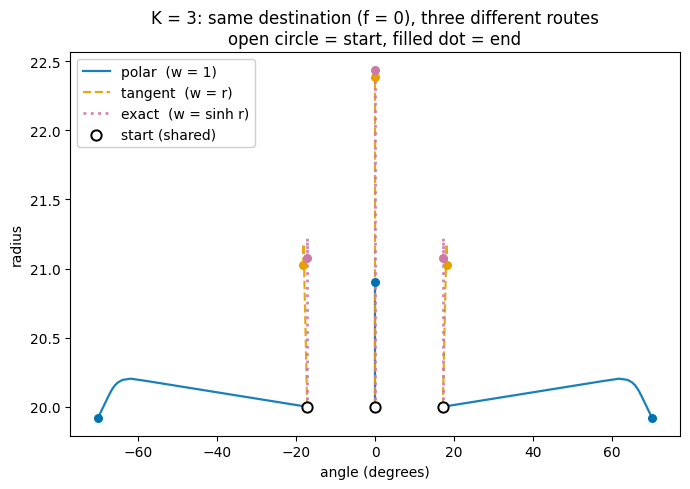

In [6]:
STYLE = {"polar  (w = 1)":      ("#0072B2", "-",  1.6),   # blue
         "tangent  (w = r)":    ("#E69F00", "--", 1.6),   # orange
         "exact  (w = sinh r)": ("#CC79A7", ":",  2.0)}   # reddish purple

fig, ax = plt.subplots(figsize=(7, 5))
for name, res in res3.items():
    colour, ls, lw = STYLE[name]
    rs = np.array([t[0] for t in res["track"]])
    ths = np.degrees(np.array([t[1] for t in res["track"]]))
    for i in range(3):
        ax.plot(ths[:, i], rs[:, i], color=colour, ls=ls, lw=lw, alpha=0.9,
                label=name if i == 0 else None)
    ax.scatter(ths[-1, :], rs[-1, :], color=colour, s=30, zorder=4)
ax.scatter(np.degrees(th0), np.full(3, R0), facecolor="white", edgecolor="black",
           s=55, linewidth=1.4, zorder=5, label="start (shared)")
ax.set_xlabel("angle (degrees)")
ax.set_ylabel("radius")
ax.set_title("K = 3: same destination (f = 0), three different routes\n"
             "open circle = start, filled dot = end")
ax.legend(loc="upper left", framealpha=0.95)
fig.tight_layout()

### $K = 4$: the radial escape route runs out

At $K = 4$ it is 4 radii against 6 distances — over-determined, so the radial
subproblem can no longer absorb an angular error. To isolate that cleanly we start
from $r^\ast = \arg\min_r f(r, \theta_{\text{init}})$: the radii already solved as
well as they can be, with the angles where they started.

This is not an artificial constraint — it is the situation every refinement in this
library is actually in. A warm start from a method's own initialisation is already
near-optimal radially, and what remains is angular.

In [7]:
def radial_solve(K, D, n=20000, lr=1e-2):
    '''r* = argmin_r f(r, theta_init): solve the radial subproblem, angles fixed.'''
    r0, V = clustered_start(K)
    r = torch.tensor(r0, requires_grad=True)
    v = torch.tensor(V)
    iu = torch.triu_indices(K, K, 1)
    opt = torch.optim.Adam([r], lr=lr)
    for _ in range(n):
        opt.zero_grad()
        d = polar_distances_torch(r, v)
        ((d[iu[0], iu[1]] - D[iu[0], iu[1]]) ** 2).sum().backward()
        opt.step()
    return r.detach().numpy(), V


D4 = targets(4)
rstar4, V4 = radial_solve(4, D4)
print(f"r* = {np.round(rstar4, 3)}\n")
print("K = 4, from r*, lr = 1e-3, 20000 steps\n")
for name, cls in CHARTS.items():
    res = descend(cls, rstar4, V4, D4, 1e-3, 20000)
    th0 = np.arctan2(V4[:, 1], V4[:, 0])
    dth = np.abs(np.angle(np.exp(1j * (res["theta"] - th0)))).mean()
    print(f"  {name:22s} f 1.2041 -> {res['f']:.6f}   "
          f"mean|dtheta| {np.degrees(dth):7.3f} deg   "
          f"mean|dr| {np.abs(res['r'] - rstar4).mean():.3f}")

r* = [21.12  22.206 22.206 21.12 ]

K = 4, from r*, lr = 1e-3, 20000 steps



  polar  (w = 1)         f 1.2041 -> 0.000000   mean|dtheta|   2.019 deg   mean|dr| 0.326


  tangent  (w = r)       f 1.2041 -> 0.000000   mean|dtheta|   1.705 deg   mean|dr| 0.327


  exact  (w = sinh r)    f 1.2041 -> 1.204059   mean|dtheta|   0.000 deg   mean|dr| 0.000


Polar and tangent turn the residual away to zero. The exact chart moves
**neither coordinate** and its loss does not change in the fourth decimal.

### No learning rate fixes this

The obvious response is that the exact chart simply needs a bigger $\lambda$. It
does not, and the reason is structural. Its step is

$$\delta r = -\lambda\,\frac{\partial f}{\partial r},
\qquad
\delta\theta = -\frac{\lambda}{\sinh^2 r}\,\frac{\partial f}{\partial\theta},$$

so the **ratio** of the two,

$$\frac{\lvert\delta r\rvert}{\lvert\delta\theta\rvert}
= \sinh^2 r\,\frac{\lvert\partial f/\partial r\rvert}{\lvert\partial f/\partial\theta\rvert},$$

is $\lambda$-free. $\lambda$ sets the step's *size*, never its *shape*. Buying a
degree of rotation costs a fixed multiple of radial havoc, whatever the rate:

In [8]:
r_probe = torch.tensor(rstar4, requires_grad=True)
th_probe = torch.tensor(np.arctan2(V4[:, 1], V4[:, 0]), requires_grad=True)
v_probe = torch.stack([torch.cos(th_probe), torch.sin(th_probe)], 1)
iu = torch.triu_indices(4, 4, 1)
d = polar_distances_torch(r_probe, v_probe)
((d[iu[0], iu[1]] - D4[iu[0], iu[1]]) ** 2).sum().backward()

g_r = r_probe.grad.abs().max().item()
g_th = th_probe.grad.abs().max().item()
sinh2 = np.sinh(rstar4.max()) ** 2
print(f"|df/dr|      = {g_r:.6e}   (r* is where the radial gradient has vanished)")
print(f"|df/dtheta|  = {g_th:.6e}")
print(f"sinh^2(r)    = {sinh2:.3e}\n")
for lam in (1e-3, 1e0, 1e3):
    dth = lam * g_th / sinh2
    print(f"  lambda = {lam:7.0e} ->  rotation {np.degrees(dth):9.3e} deg,"
          f"  radial move {lam * g_r:9.3e}")

|df/dr|      = 1.700042e-08   (r* is where the radial gradient has vanished)
|df/dtheta|  = 2.255652e+01
sinh^2(r)    = 4.847e+18

  lambda =   1e-03 ->  rotation 2.667e-19 deg,  radial move 1.700e-11
  lambda =   1e+00 ->  rotation 2.667e-16 deg,  radial move 1.700e-08
  lambda =   1e+03 ->  rotation 2.667e-13 deg,  radial move 1.700e-05


## 5. $K = 5$: two quite different ways of being stuck

One more point, and the picture stops being a story about the exact chart alone.

In [9]:
def coord_grad_norm(r_np, th_np, D):
    '''||(df/dr, df/dtheta)|| in raw polar coordinates.

    This is the same function of position for every chart -- they all parametrise
    by the same (r, theta) -- so the loss is stationary exactly where it vanishes.
    That makes it the diagnostic that separates 'converged' from 'immobile'.
    '''
    K = len(r_np)
    r = torch.tensor(r_np, requires_grad=True)
    th = torch.tensor(th_np, requires_grad=True)
    v = torch.stack([torch.cos(th), torch.sin(th)], 1)
    iu = torch.triu_indices(K, K, 1)
    d = polar_distances_torch(r, v)
    ((d[iu[0], iu[1]] - D[iu[0], iu[1]]) ** 2).sum().backward()
    return float(torch.cat([r.grad, th.grad]).norm())


D5 = targets(5)
rstar5, V5 = radial_solve(5, D5)
print("K = 5, from r* (start f = 3.1159), lr = 3e-3, 20000 steps\n")
print(f"  {'chart':22s} {'final f':>10}   {'||coord grad||':>14}")
for name, cls in CHARTS.items():
    res = descend(cls, rstar5, V5, D5, 3e-3, 20000)
    g = coord_grad_norm(res["r"], res["theta"], D5)
    print(f"  {name:22s} {res['f']:10.6f}   {g:14.3e}")

K = 5, from r* (start f = 3.1159), lr = 3e-3, 20000 steps

  chart                     final f   ||coord grad||


  polar  (w = 1)           2.910026        8.264e-13


  tangent  (w = r)         0.000000        3.454e-12


  exact  (w = sinh r)      3.115900        6.219e+01


Three outcomes, and the gradient column is what separates them.

- **Tangent** reaches zero, with a vanishing gradient. It solved the problem.
- **Polar** stops short of zero — and its gradient has also vanished, to
  $\sim\!10^{-13}$. It is at a **genuine local minimum**: its large angular steps
  carried it into a basin it cannot leave. It reaches the same value at
  $\lambda = 10^{-3}$, $3\times10^{-3}$ and $10^{-2}$, and holds it from 20 000
  steps through 100 000, so this is not over-stepping.
- **Exact** has not moved at all, and its gradient is **62.19** — enormous. It is
  **not at a stationary point**. It sits at a perfectly ordinary place on the
  landscape, with a large and correctly-signed gradient it cannot act on.

Two flat loss curves that mean entirely different things.

**One honest qualification**, since it is the strongest objection to the framing
above. Measured in the *true* metric of $\mathbb{H}^2$ rather than in coordinates,
the exact chart's sticking point does have a small gradient: the angular term
carries a $1/\sinh r$, which at $r \approx 22$ is $\sim\!10^{-8}$. The exact chart
is not broken. It is correctly pricing rotation at that radius as enormously
expensive — which is a true fact about hyperbolic space. The difficulty is that
**expensive and unavailable are not the same thing**, and a method that measures
its steps this way will never pay a cost it has correctly priced. The other two
charts are wrong about the price, and arrive.

And in these methods the angle is exactly what has to move. The radius carries
popularity — degree, hub-ness, depth in a hierarchy — while the angle carries
similarity, so a refinement's job is largely to rearrange angles at radii the
initialisation already has roughly right. The true metric's own answer to "how do I
change an angle cheaply out here?" is: *don't do it out here*. The geodesic joining
two points at the same radius $r$, separated by $\Delta\theta$, dips to
$\operatorname{artanh}(\tanh r \cdot \cos(\Delta\theta/2))$ at its closest approach to
the origin — for a $72^\circ$ move that is $r \approx 1.12$, essentially wherever the
points started. Taken literally, a leaf at $r \approx 22$ would reach its new angle by
falling through the centre of the disk and climbing back out: mid-flight, the least
popular node in the graph is the most central one. The cheapest correct path is one no
model of this kind would want to travel.

To be exact about what the chart does: `exact_polar` never travels that geodesic. It
takes short steps along the gradient — and above it took none at all. The geodesic is
what its *pricing* rests on, not its trajectory. The two are the same fact seen from
either side: the $\sinh^2 r$ that makes the route around the rim expensive is the same
$\sinh^2 r$ its angular gradient is divided by.

## 6. Only one of those two failures is real

Everything so far used plain gradient descent, which is what made a single shared
learning rate a fair comparison. But it is not what the library runs: every
gradient method here uses `RiemannianAdam`, which rescales the step by the
gradient's own magnitude. Both failures have to be re-examined under it, and they
do **not** behave the same way.

In [10]:
print("K = 5 from r*, RiemannianAdam via the library's optimiser, 5000 steps.  Final f:\n")
print(f"  {'chart':22s}" + "".join(f"{f'lr={lr:g}':>14}" for lr in (1e-4, 1e-3, 1e-2)))
for name, cls in CHARTS.items():
    row = ""
    for lr in (1e-4, 1e-3, 1e-2):
        rep = cls.from_polar(rstar5, V5)
        # hypeGRL's fixed-target optimiser, the one every embedder here calls.
        # `stress` already has the (representation, s_A) signature it expects:
        # this toy is an instance of the same encoder-decoder contract, with the
        # target distances as s_A. grad_clip=0 keeps the update a pure Adam step.
        riemannian_optimize(rep, D5.numpy(), stress, lr=lr, n_steps=5000,
                            grad_clip=0, log_every=0)
        row += f"{stress(rep, D5).item():14.6f}"
    print(f"  {name:22s}" + row)

K = 5 from r*, RiemannianAdam via the library's optimiser, 5000 steps.  Final f:

  chart                      lr=0.0001      lr=0.001       lr=0.01


  polar  (w = 1)              0.050426      0.000000      0.000000


  tangent  (w = r)            1.140455      0.000000      0.000000


  exact  (w = sinh r)         3.115900      3.115900      3.115900


**Polar's local minimum is gone.** It reaches zero at both rates that converge
within this budget, and at the slowest rate it is still descending (0.05, down
from 3.12) rather than settled. The basin that trapped it under plain gradient
descent is not a feature of the chart at all — it is what a fixed-size step
following the raw gradient did on the way there, and an adaptive optimiser walks
out of it.

**The exact chart is frozen at the value it started from**, at every rate, to six
decimals — not descending slowly, as tangent is in the first column, but not
descending.

That asymmetry has a clean cause, and it is the practical lesson here. The division
by $\sinh^2 r$ happens **inside the chart**, when the coordinate gradient is turned
into a step — *before* any optimiser sees it. Adam can rescale what it receives; it
cannot restore what was annihilated upstream. Polar's failure was about the step's
*size*, which is exactly what an adaptive method is for; the exact chart's is about
what reaches the optimiser at all.

So of the two ways to get the angular-to-radial ratio wrong, **one belongs to the
optimiser and is fixable, and the other belongs to the chart and is not.**

## 7. So which chart should you use?

Not a ranking — the evidence above does not support one, and it is worth being
precise about how little it supports. Under the optimiser the library actually
uses, `polar` and `tangent` **both solve every problem in this tutorial**. The toy
separates the exact chart from the other two; it does not separate those two from
each other.

**What the chart controls is the ratio between angular and radial motion.** There
are two ways to get it wrong, and §6 showed they are not equally serious: too
large, and a fixed-step optimiser jumps a basin — which an adaptive one fixes; too
small, and the angular gradient never reaches the optimiser at all — which nothing
fixes.

**Geometric correctness and optimisation performance are not the same axis.**
Ordered by fidelity to $\mathbb{H}^{D+1}$ the ranking is exact > tangent > polar;
in the toy above it runs the other way. This is the natural gradient of §2 turning
up with the sign reversed: measuring steps in the true metric of the space is the
principled choice, and it is not automatically the fastest descent — in hyperbolic
space, where volume grows like $e^{r}$, it can be no descent at all. The exact
chart is not wrong about the geometry. It is right about it, and stuck.

**The tangent chart is not a free win either.** It carries a cost the others do
not: under `RiemannianAdam` its Cartesian storage makes the optimisation depend on
the coordinate frame, so rotating a whole configuration — a no-op for the model,
since the loss sees only distances — can change the result. `polar` and
`exact_polar` are exactly equivariant. The class documentation for
[TangentRepresentation](../api/representations.rst) has the mechanism.

**Scope.** One configuration family, a handful of learning rates, a single seed,
and a loss built directly on distances. What is established here is a mechanism
and its arithmetic — not a general ranking of charts, and not a recommendation to
change a default. `polar` remains the library default because it is exact at every
radius and keeps moving the angles; when a fit refuses to improve on a
large-radius warm start, this tutorial is the reason to try `representation=` as a
knob rather than assuming the optimiser has converged.